# Session 2: 모델링 기초와 피처 엔지니어링

**집값 예측 ML 프로젝트 - 2회차**

---

## 학습 목표

1. LightGBM(Gradient Boosting)의 학습 원리를 이해한다
2. Baseline 모델을 학습하고 성능을 측정한다
3. 피처 엔지니어링 기법을 실습하고 성능 개선을 확인한다

| 구분 | 내용 |
|------|------|
| 이론 | LightGBM 학습 원리 (Decision Tree, Gradient Boosting) |
| 실습 | Baseline 모델 학습 + 피처 엔지니어링으로 성능 개선 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

# 한글 깨짐 방지 (macOS 환경)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# 재현성을 위한 시드 고정
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('라이브러리 로딩 완료!')

라이브러리 로딩 완료!


---

# Part 1: 이론

---

## 1.1 핵심 개념: LightGBM

정형 데이터(표 형식) ML의 핵심 모델을 단계적으로 이해해 봅시다.

| 단계 | 개념 | 한줄 설명 |
|------|------|-----------|
| 1단계 | **Decision Tree** | 조건 분기(if-else)로 예측하는 기본 모델 |
| 2단계 | **Gradient Boosting** | 여러 트리가 순서대로 오차를 보정 |
| 3단계 | **LightGBM** | 가장 빠르고 정확한 Gradient Boosting 구현체 |

### 왜 정형 데이터에서 GBT가 강한가?

정형 데이터(테이블)에서는 딥러닝(Neural Network)보다 **Gradient Boosting Tree가 압도적으로 강력**합니다:

- **혼합 타입**: 숫자와 카테고리가 섞인 데이터를 자연스럽게 처리
- **결측값**: 별도 전처리 없이 빈 값을 자동으로 처리
- **적은 데이터**: 수천~수만 행에서도 높은 성능 (딥러닝은 대규모 데이터 필요)
- **해석 가능성**: 어떤 피처가 중요한지 직접 확인 가능
- **학습 속도**: 빠른 학습과 추론

> Kaggle 정형 데이터 대회의 ~80%가 GBT 계열(LightGBM, XGBoost)로 우승했습니다.
>
> **LightGBM** = Leaf-wise 트리 성장 + 히스토그램 기반 분할 → GBT 중 가장 빠르고 정확한 구현체

핵심 정리:
  1. Decision Tree 학습 = 오차를 가장 줄이는 분할점을 데이터에서 탐색하여 재귀 분할
  2. Gradient Boosting 학습 = 이전 트리의 잔차(실수)를 다음 트리의 학습 데이터로 전달
  3. 매 라운드마다 피처(입력)는 동일하고, 타겟만 잔차로 바뀜 → 각 트리가 다른 피처에 집중
  4. 이 과정을 100~1000번 반복하면 잔차 → 0 수렴 → 정확한 예측
  5. LightGBM = 이 Gradient Boosting을 가장 효율적으로 수행하는 구현체


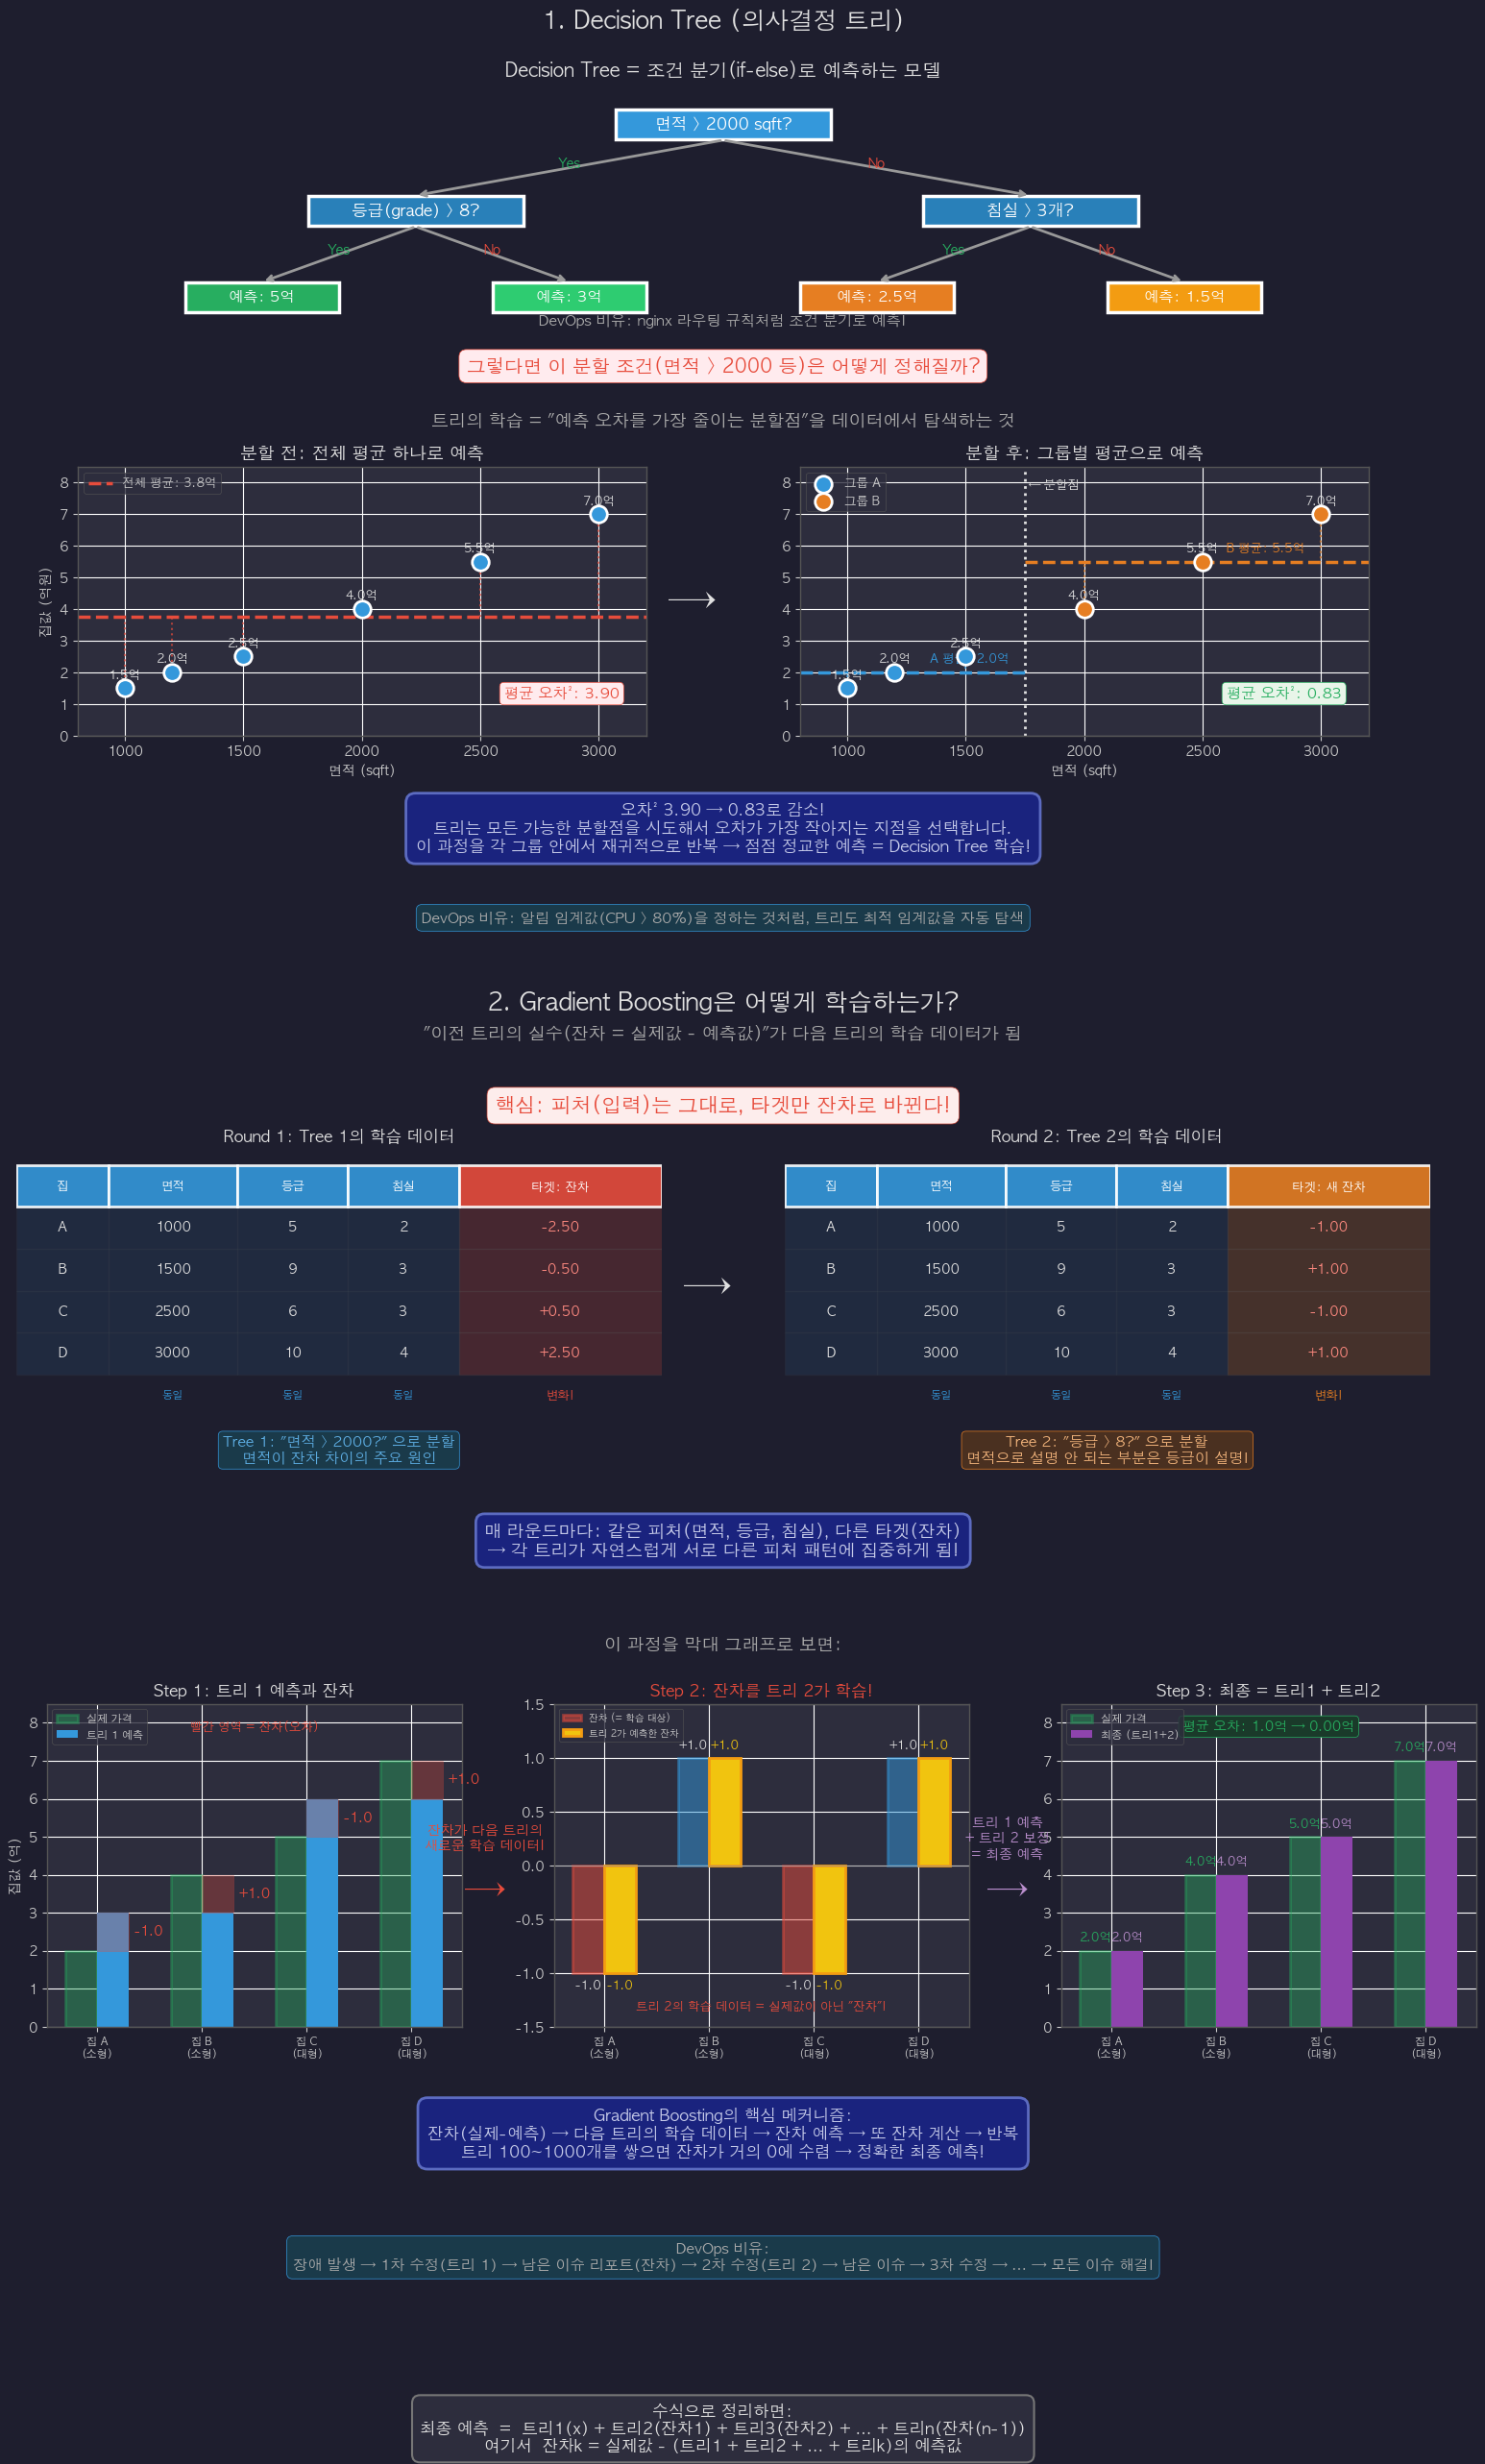

In [2]:
fig = plt.figure(figsize=(16, 28))
fig.patch.set_facecolor('#1e1e2e')

# Dark theme helper
def style_ax(ax):
    ax.set_facecolor('#2d2d3d')
    ax.tick_params(colors='#CCC')
    for spine in ax.spines.values():
        spine.set_color('#555')

# =====================================================================
# Panel 1: Decision Tree (의사결정 트리)
# =====================================================================
fig.text(0.5, 0.99, '1. Decision Tree (의사결정 트리)',
         fontsize=18, fontweight='bold', ha='center', va='top', color='#E0E0E0')

# --- 1a: 트리 구조 다이어그램 ---
ax_tree = fig.add_axes([0.10, 0.87, 0.80, 0.09])
ax_tree.set_xlim(0, 16)
ax_tree.set_ylim(-0.5, 6.5)
ax_tree.axis('off')
ax_tree.set_facecolor('#1e1e2e')
ax_tree.set_title('Decision Tree = 조건 분기(if-else)로 예측하는 모델',
                   fontsize=14, fontweight='bold', pad=10, color='#E0E0E0')

def node(ax, x, y, t, c, w=2.8, h=0.85, fs=12):
    ax.add_patch(plt.Rectangle((x-w/2, y-h/2), w, h, fc=c, ec='white', lw=2.5, zorder=3))
    ax.text(x, y, t, ha='center', va='center', fontsize=fs,
            fontweight='bold', color='white', zorder=4)

node(ax_tree, 8, 5.5, '면적 > 2000 sqft?', '#3498DB')
node(ax_tree, 4, 3, '등급(grade) > 8?', '#2980B9')
node(ax_tree, 12, 3, '침실 > 3개?', '#2980B9')
for x, p, c in [(2,'5억','#27AE60'), (6,'3억','#2ECC71'),
                 (10,'2.5억','#E67E22'), (14,'1.5억','#F39C12')]:
    node(ax_tree, x, 0.5, f'예측: {p}', c, w=2.0, fs=11)

for x1, y1, x2, y2, lbl in [(8,5.05,4,3.45,'Yes'), (8,5.05,12,3.45,'No'),
                              (4,2.55,2,0.95,'Yes'), (4,2.55,6,0.95,'No'),
                              (12,2.55,10,0.95,'Yes'), (12,2.55,14,0.95,'No')]:
    ax_tree.annotate('', xy=(x2,y2), xytext=(x1,y1),
                     arrowprops=dict(arrowstyle='->', color='#999', lw=2))
    clr = '#27AE60' if lbl == 'Yes' else '#E74C3C'
    ax_tree.text((x1+x2)/2, (y1+y2)/2, lbl, fontsize=10, ha='center',
                 color=clr, fontweight='bold')

ax_tree.text(8, -0.3, 'DevOps 비유: nginx 라우팅 규칙처럼 조건 분기로 예측!',
             fontsize=11, ha='center', style='italic', color='#AAAAAA')

# --- Transition ---
fig.text(0.5, 0.855,
         '그렇다면 이 분할 조건(면적 > 2000 등)은 어떻게 정해질까?',
         fontsize=14, ha='center', fontweight='bold', color='#E74C3C',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#E74C3C'))

fig.text(0.5, 0.835,
         '트리의 학습 = "예측 오차를 가장 줄이는 분할점"을 데이터에서 탐색하는 것',
         fontsize=13, ha='center', color='#AAAAAA', style='italic')

areas = np.array([1000, 1200, 1500, 2000, 2500, 3000])
prices = np.array([1.5, 2.0, 2.5, 4.0, 5.5, 7.0])
avg_all = prices.mean()

# 분할 전
ax1a = fig.add_axes([0.08, 0.72, 0.37, 0.10])
style_ax(ax1a)
ax1a.scatter(areas, prices, s=160, c='#3498DB', edgecolor='white', lw=2, zorder=5)
ax1a.axhline(avg_all, color='#E74C3C', ls='--', lw=2.5,
             label=f'전체 평균: {avg_all:.1f}억')
for a, p in zip(areas, prices):
    ax1a.plot([a, a], [p, avg_all], color='#E74C3C', lw=1.5, ls=':', alpha=0.7)
    ax1a.text(a, p + 0.3, f'{p}억', fontsize=9, ha='center', color='#E0E0E0')
ax1a.set_title('분할 전: 전체 평균 하나로 예측', fontsize=13, fontweight='bold', color='#E0E0E0')
ax1a.set_xlabel('면적 (sqft)', fontsize=10, color='#CCCCCC')
ax1a.set_ylabel('집값 (억원)', fontsize=10, color='#CCCCCC')
ax1a.legend(fontsize=9, loc='upper left', facecolor='#2d2d3d', edgecolor='#555', labelcolor='#CCC')
mse_before = np.mean((prices - avg_all) ** 2)
ax1a.text(2600, 1.2, f'평균 오차²: {mse_before:.2f}', fontsize=11,
          color='#E74C3C', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#E74C3C'))
ax1a.set_xlim(800, 3200)
ax1a.set_ylim(0, 8.5)

fig.text(0.48, 0.77, '→', fontsize=35, ha='center', va='center',
         color='#E0E0E0', fontweight='bold')

# 분할 후
ax1b = fig.add_axes([0.55, 0.72, 0.37, 0.10])
style_ax(ax1b)
ax1b.scatter(areas[:3], prices[:3], s=160, c='#3498DB', edgecolor='white',
             lw=2, zorder=5, label='그룹 A')
ax1b.scatter(areas[3:], prices[3:], s=160, c='#E67E22', edgecolor='white',
             lw=2, zorder=5, label='그룹 B')
ax1b.axvline(1750, color='#E0E0E0', ls=':', lw=2)
ax1b.text(1760, 7.8, '← 분할점', fontsize=9, color='#E0E0E0')

left_avg = prices[:3].mean()
right_avg = prices[3:].mean()
ax1b.hlines(left_avg, 800, 1750, colors='#3498DB', ls='--', lw=2.5)
ax1b.hlines(right_avg, 1750, 3200, colors='#E67E22', ls='--', lw=2.5)
ax1b.text(1350, left_avg + 0.3, f'A 평균: {left_avg:.1f}억', fontsize=9,
          color='#3498DB', fontweight='bold')
ax1b.text(2600, right_avg + 0.3, f'B 평균: {right_avg:.1f}억', fontsize=9,
          color='#E67E22', fontweight='bold')

for a, p, avg in list(zip(areas[:3], prices[:3], [left_avg]*3)) + \
                  list(zip(areas[3:], prices[3:], [right_avg]*3)):
    c2 = '#3498DB' if a < 1750 else '#E67E22'
    ax1b.plot([a, a], [p, avg], color=c2, lw=1.5, ls=':', alpha=0.7)
    ax1b.text(a, p + 0.3, f'{p}억', fontsize=9, ha='center', color='#E0E0E0')

ax1b.set_title('분할 후: 그룹별 평균으로 예측', fontsize=13, fontweight='bold', color='#E0E0E0')
ax1b.set_xlabel('면적 (sqft)', fontsize=10, color='#CCCCCC')
ax1b.legend(fontsize=9, loc='upper left', facecolor='#2d2d3d', edgecolor='#555', labelcolor='#CCC')
preds = np.where(areas < 1750, left_avg, right_avg)
mse_after = np.mean((prices - preds) ** 2)
ax1b.text(2600, 1.2, f'평균 오차²: {mse_after:.2f}', fontsize=11,
          color='#27AE60', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#27AE60'))
ax1b.set_xlim(800, 3200)
ax1b.set_ylim(0, 8.5)

# 핵심 인사이트
fig.text(0.5, 0.695,
         f'오차² {mse_before:.2f} → {mse_after:.2f}로 감소!\n'
         '트리는 모든 가능한 분할점을 시도해서 오차가 가장 작아지는 지점을 선택합니다.\n'
         '이 과정을 각 그룹 안에서 재귀적으로 반복 → 점점 정교한 예측 = Decision Tree 학습!',
         fontsize=12, ha='center', va='top', color='#C5CAE9',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#1A237E', edgecolor='#5C6BC0', lw=2))

fig.text(0.5, 0.655,
         'DevOps 비유: 알림 임계값(CPU > 80%)을 정하는 것처럼, 트리도 최적 임계값을 자동 탐색',
         fontsize=11, ha='center', va='top', color='#AAAAAA', style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a3a4a', edgecolor='#3498DB'))

# =====================================================================
# Panel 2: Gradient Boosting의 잔차 학습 메커니즘
# =====================================================================
fig.text(0.5, 0.625, '2. Gradient Boosting은 어떻게 학습하는가?',
         fontsize=18, fontweight='bold', ha='center', va='top', color='#E0E0E0')
fig.text(0.5, 0.607,
         '"이전 트리의 실수(잔차 = 실제값 - 예측값)"가 다음 트리의 학습 데이터가 됨',
         fontsize=13, ha='center', color='#AAAAAA', style='italic')

# =====================================================================
# NEW: 다중 피처 학습 과정 테이블
# =====================================================================
fig.text(0.5, 0.58,
         '핵심: 피처(입력)는 그대로, 타겟만 잔차로 바뀐다!',
         fontsize=15, ha='center', fontweight='bold', color='#E74C3C',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDEDEC', edgecolor='#C0392B'))

# 테이블 그리기 함수
def draw_data_table(ax, title, col_headers, rows, feat_color, target_color):
    ax.axis('off')
    ax.set_facecolor('#1e1e2e')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8, color='#E0E0E0')
    n_cols = len(col_headers)
    n_rows = len(rows)
    col_w = [1.0, 1.4, 1.2, 1.2, 2.2]
    total_w = sum(col_w)
    cell_h = 1.0
    ax.set_xlim(0, total_w)
    ax.set_ylim(-0.8, (n_rows + 1) * cell_h + 0.3)

    for row_idx in range(-1, n_rows):
        is_header = (row_idx == -1)
        y_center = (n_rows - row_idx - 0.5) * cell_h
        x_pos = 0
        vals = col_headers if is_header else rows[row_idx]
        for col_idx, (val, cw) in enumerate(zip(vals, col_w)):
            is_target = (col_idx == n_cols - 1)
            if is_header:
                fc = target_color if is_target else feat_color
                rect = plt.Rectangle((x_pos, y_center - cell_h/2), cw, cell_h,
                                     fc=fc, ec='white', lw=2, alpha=0.9, zorder=2)
                ax.add_patch(rect)
                ax.text(x_pos + cw/2, y_center, val, fontsize=9, ha='center',
                        va='center', color='white', fontweight='bold', zorder=3)
            else:
                fc = target_color if is_target else feat_color
                alp = 0.20 if is_target else 0.10
                rect = plt.Rectangle((x_pos, y_center - cell_h/2), cw, cell_h,
                                     fc=fc, ec='#555', lw=1, alpha=alp, zorder=1)
                ax.add_patch(rect)
                tc = '#FF8A80' if is_target else '#E0E0E0'
                fw = 'bold' if is_target else 'normal'
                ax.text(x_pos + cw/2, y_center, str(val), fontsize=10, ha='center',
                        va='center', color=tc, fontweight=fw, zorder=3)
            x_pos += cw

    # 하단 라벨
    x_pos = 0
    for col_idx, cw in enumerate(col_w):
        if 0 < col_idx < n_cols - 1:
            ax.text(x_pos + cw/2, -0.5, '동일', fontsize=8, ha='center',
                    va='center', color=feat_color, fontweight='bold')
        elif col_idx == n_cols - 1:
            ax.text(x_pos + cw/2, -0.5, '변화!', fontsize=9, ha='center',
                    va='center', color=target_color, fontweight='bold')
        x_pos += cw

# Round 1 테이블
ax_t1 = fig.add_axes([0.04, 0.47, 0.42, 0.095])
draw_data_table(ax_t1,
    'Round 1: Tree 1의 학습 데이터',
    ['집', '면적', '등급', '침실', '타겟: 잔차'],
    [['A', '1000', '5', '2', '-2.50'],
     ['B', '1500', '9', '3', '-0.50'],
     ['C', '2500', '6', '3', '+0.50'],
     ['D', '3000', '10', '4', '+2.50']],
    '#3498DB', '#E74C3C')

# 테이블 사이 화살표
fig.text(0.49, 0.515, '→', fontsize=35, ha='center', va='center', color='#E0E0E0')

# Round 2 테이블
ax_t2 = fig.add_axes([0.54, 0.47, 0.42, 0.095])
draw_data_table(ax_t2,
    'Round 2: Tree 2의 학습 데이터',
    ['집', '면적', '등급', '침실', '타겟: 새 잔차'],
    [['A', '1000', '5', '2', '-1.00'],
     ['B', '1500', '9', '3', '+1.00'],
     ['C', '2500', '6', '3', '-1.00'],
     ['D', '3000', '10', '4', '+1.00']],
    '#3498DB', '#E67E22')

# 트리 분할 설명
fig.text(0.25, 0.45,
         'Tree 1: "면적 > 2000?" 으로 분할\n면적이 잔차 차이의 주요 원인',
         fontsize=11, ha='center', color='#5DADE2', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a3a4a', edgecolor='#3498DB'))

fig.text(0.75, 0.45,
         'Tree 2: "등급 > 8?" 으로 분할\n면적으로 설명 안 되는 부분은 등급이 설명!',
         fontsize=11, ha='center', color='#F0B27A', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#4a3020', edgecolor='#E67E22'))

# 핵심 콜아웃
fig.text(0.5, 0.415,
         '매 라운드마다: 같은 피처(면적, 등급, 침실), 다른 타겟(잔차)\n'
         '→ 각 트리가 자연스럽게 서로 다른 피처 패턴에 집중하게 됨!',
         fontsize=13, ha='center', color='#C5CAE9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1A237E', edgecolor='#5C6BC0', lw=2))

# =====================================================================
# Panel 2b: 잔차 학습 메커니즘 (Step 1-2-3 막대 그래프)
# =====================================================================
fig.text(0.5, 0.38,
         '이 과정을 막대 그래프로 보면:',
         fontsize=13, ha='center', color='#AAAAAA', fontweight='bold')

houses = ['집 A\n(소형)', '집 B\n(소형)', '집 C\n(대형)', '집 D\n(대형)']
actual = np.array([2.0, 4.0, 5.0, 7.0])
tree1 = np.array([3.0, 3.0, 6.0, 6.0])
residual1 = actual - tree1
tree2_corr = np.array([-1.0, 1.0, -1.0, 1.0])
final = tree1 + tree2_corr
x = np.arange(4)
w = 0.30

# Step 1: 트리 1 예측
ax2a = fig.add_axes([0.06, 0.24, 0.27, 0.12])
style_ax(ax2a)
ax2a.bar(x - w/2, actual, w, color='#27AE60', alpha=0.4,
         edgecolor='#27AE60', lw=2, label='실제 가격')
ax2a.bar(x + w/2, tree1, w, color='#3498DB', label='트리 1 예측')
for i in range(4):
    y_lo = min(actual[i], tree1[i])
    y_hi = max(actual[i], tree1[i])
    ax2a.fill_between([i + w/2 - w/2, i + w/2 + w/2], y_lo, y_hi,
                       color='#E74C3C', alpha=0.3, zorder=2)
    ax2a.text(i + 0.35, (actual[i] + tree1[i]) / 2, f'{residual1[i]:+.1f}',
              fontsize=10, color='#E74C3C', fontweight='bold', va='center')
ax2a.set_xticks(x)
ax2a.set_xticklabels(houses, fontsize=8)
ax2a.set_ylabel('집값 (억)', fontsize=10, color='#CCCCCC')
ax2a.set_title('Step 1: 트리 1 예측과 잔차', fontsize=12, fontweight='bold', color='#E0E0E0')
ax2a.legend(fontsize=8, loc='upper left', facecolor='#2d2d3d', edgecolor='#555', labelcolor='#CCC')
ax2a.set_ylim(0, 8.5)
ax2a.text(1.5, 7.8, '빨간 영역 = 잔차(오차)', fontsize=9, color='#E74C3C',
          ha='center', fontweight='bold')

fig.text(0.345, 0.31, '잔차가 다음 트리의\n새로운 학습 데이터!',
         fontsize=10, ha='center', va='center', color='#E74C3C', fontweight='bold')
fig.text(0.345, 0.29, '→', fontsize=30, ha='center', va='center', color='#E74C3C')

# Step 2: 트리 2가 잔차를 학습
ax2b = fig.add_axes([0.39, 0.24, 0.27, 0.12])
style_ax(ax2b)
res_colors = ['#E74C3C' if r < 0 else '#3498DB' for r in residual1]
ax2b.bar(x - w/2, residual1, w, color=res_colors, alpha=0.5,
         edgecolor=res_colors, lw=2, label='잔차 (= 학습 대상)')
ax2b.bar(x + w/2, tree2_corr, w, color='#F1C40F',
         edgecolor='#F39C12', lw=2, label='트리 2가 예측한 잔차')
ax2b.axhline(0, color='#999', lw=0.5)
for i in range(4):
    offset = 0.08 if residual1[i] > 0 else -0.15
    ax2b.text(i - w/2, residual1[i] + offset, f'{residual1[i]:+.1f}',
              fontsize=9, ha='center', color='#E0E0E0', fontweight='bold')
    offset2 = 0.08 if tree2_corr[i] > 0 else -0.15
    ax2b.text(i + w/2, tree2_corr[i] + offset2, f'{tree2_corr[i]:+.1f}',
              fontsize=9, ha='center', color='#F1C40F', fontweight='bold')
ax2b.set_xticks(x)
ax2b.set_xticklabels(houses, fontsize=8)
ax2b.set_title('Step 2: 잔차를 트리 2가 학습!', fontsize=12,
               fontweight='bold', color='#E74C3C')
ax2b.legend(fontsize=7, loc='upper left', facecolor='#2d2d3d', edgecolor='#555', labelcolor='#CCC')
ax2b.set_ylim(-1.5, 1.5)
ax2b.text(1.5, -1.35, '트리 2의 학습 데이터 = 실제값이 아닌 "잔차"!',
          fontsize=9, ha='center', color='#E74C3C', style='italic', fontweight='bold')

fig.text(0.685, 0.31, '트리 1 예측\n+ 트리 2 보정\n= 최종 예측',
         fontsize=10, ha='center', va='center', color='#BB8FCE', fontweight='bold')
fig.text(0.685, 0.29, '→', fontsize=30, ha='center', va='center', color='#BB8FCE')

# Step 3: 최종
ax2c = fig.add_axes([0.72, 0.24, 0.27, 0.12])
style_ax(ax2c)
ax2c.bar(x - w/2, actual, w, color='#27AE60', alpha=0.4,
         edgecolor='#27AE60', lw=2, label='실제 가격')
ax2c.bar(x + w/2, final, w, color='#8E44AD', label='최종 (트리1+2)')
for i in range(4):
    ax2c.text(i + w/2, final[i] + 0.25, f'{final[i]:.1f}억', fontsize=9,
              ha='center', color='#BB8FCE', fontweight='bold')
    ax2c.text(i - w/2, actual[i] + 0.25, f'{actual[i]:.1f}억', fontsize=9,
              ha='center', color='#27AE60', fontweight='bold')
ax2c.set_xticks(x)
ax2c.set_xticklabels(houses, fontsize=8)
ax2c.set_title('Step 3: 최종 = 트리1 + 트리2', fontsize=12, fontweight='bold', color='#E0E0E0')
ax2c.legend(fontsize=8, loc='upper left', facecolor='#2d2d3d', edgecolor='#555', labelcolor='#CCC')
ax2c.set_ylim(0, 8.5)
err1 = np.mean(np.abs(actual - tree1))
err_final = np.mean(np.abs(actual - final))
ax2c.text(1.5, 7.8, f'평균 오차: {err1:.1f}억 → {err_final:.2f}억',
          fontsize=10, ha='center', color='#27AE60', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a3a2a', edgecolor='#27AE60'))

# Gradient Boosting 핵심 인사이트
fig.text(0.5, 0.21,
         'Gradient Boosting의 핵심 메커니즘:\n'
         '잔차(실제-예측) → 다음 트리의 학습 데이터 → 잔차 예측 → 또 잔차 계산 → 반복\n'
         '트리 100~1000개를 쌓으면 잔차가 거의 0에 수렴 → 정확한 최종 예측!',
         fontsize=12, ha='center', va='top', color='#C5CAE9',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#1A237E', edgecolor='#5C6BC0', lw=2))

fig.text(0.5, 0.16,
         'DevOps 비유:\n'
         '장애 발생 → 1차 수정(트리 1) → 남은 이슈 리포트(잔차) → '
         '2차 수정(트리 2) → 남은 이슈 → 3차 수정 → ... → 모든 이슈 해결!',
         fontsize=11, ha='center', va='top', color='#AAAAAA', style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a3a4a', edgecolor='#3498DB'))

# 수식 정리
fig.text(0.5, 0.10,
         '수식으로 정리하면:\n'
         '최종 예측  =  트리1(x) + 트리2(잔차1) + 트리3(잔차2) + ... + 트리n(잔차(n-1))\n'
         '여기서  잔차k = 실제값 - (트리1 + 트리2 + ... + 트리k)의 예측값',
         fontsize=12, ha='center', va='top', color='#E0E0E0',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2d2d3d',
                   edgecolor='#777', lw=1.5))


print('핵심 정리:')
print('  1. Decision Tree 학습 = 오차를 가장 줄이는 분할점을 데이터에서 탐색하여 재귀 분할')
print('  2. Gradient Boosting 학습 = 이전 트리의 잔차(실수)를 다음 트리의 학습 데이터로 전달')
print('  3. 매 라운드마다 피처(입력)는 동일하고, 타겟만 잔차로 바뀜 → 각 트리가 다른 피처에 집중')
print('  4. 이 과정을 100~1000번 반복하면 잔차 → 0 수렴 → 정확한 예측')
print('  5. LightGBM = 이 Gradient Boosting을 가장 효율적으로 수행하는 구현체')

## 1.2 피처 엔지니어링이란?

**피처 엔지니어링(Feature Engineering)** 은 원본 데이터를 가공하여 모델이 더 잘 학습할 수 있도록 돕는 과정입니다.

### DevOps 비유

여러분이 서버 모니터링 대시보드를 만든다고 생각해 보세요.

| 원본 로그 데이터 | 파생 메트릭 (피처 엔지니어링) |
|------------------|-----------------------------|
| 개별 요청 로그 | **에러율** = 에러 수 / 전체 요청 수 |
| 응답 시간 목록 | **p99 응답시간** = 상위 1% 응답시간 |
| CPU 사용량 (시계열) | **CPU 트렌드** = 지난 1시간 평균 대비 증감 |
| 배포 타임스탬프 | **배포 후 경과 시간** = 현재 - 마지막 배포 시각 |

원본 로그 자체보다, 이렇게 **가공된 메트릭**이 장애를 탐지하는 데 훨씬 유용하죠.

ML도 마찬가지입니다. 원본 데이터 그대로보다, **도메인 지식을 반영해 가공한 피처**가 모델 성능을 크게 향상시킵니다.

> **"데이터와 피처가 ML 프로젝트의 성능 한계를 결정하고, 모델과 알고리즘은 그 한계에 얼마나 가까이 다가갈 수 있느냐를 결정한다."**
> 
> \- Andrew Ng

## 1.3 주요 기법

오늘 실습할 피처 엔지니어링 기법들을 먼저 살펴보겠습니다.

### 1) 로그 변환 (Log Transformation)

- **목적**: 한쪽으로 치우친(skewed) 분포를 정규분포에 가깝게 보정
- **적용**: `np.log1p(x)` (log(1+x), 0인 값도 안전하게 처리)
- **DevOps 비유**: 응답시간이 대부분 10ms이고 가끔 10,000ms인 경우, 로그 스케일로 보면 패턴이 더 잘 보이는 것과 같습니다

### 2) 비율 피처 (Ratio Features)

- **목적**: 두 피처 간의 관계를 하나의 숫자로 표현
- **예시**: `욕실 수 / 침실 수`, `거주 면적 / 층수`
- **DevOps 비유**: `요청 성공률 = 성공 응답 / 전체 요청`처럼, 절대값보다 비율이 더 의미 있는 경우가 많습니다

### 3) 불리언 피처 (Boolean Features)

- **목적**: 연속형 값을 "있다/없다"로 단순화
- **예시**: `지하실이 있는가?`, `리모델링을 했는가?`
- **DevOps 비유**: CPU 사용량 60.5%라는 숫자보다, `is_overloaded = CPU > 80%`라는 불리언이 알림 규칙에 더 유용한 것과 같습니다

### 4) 카테고리 인코딩 (One-Hot Encoding)

- **목적**: 문자열 카테고리를 숫자로 변환
- **방법**: 각 카테고리 값을 별도의 0/1 컬럼으로 분리
- **DevOps 비유**: 서버 리전을 `us-east=1, eu-west=0, ap-northeast=0`처럼 표현하는 것

---

# Part 2: 실습

---

## Step 1: 데이터 로딩 (1회차 복습)

1회차에서 배운 데이터 로딩 과정을 다시 수행합니다.
- train/test 데이터를 합쳐서 한 번에 피처 엔지니어링
- 이상치(outlier) 제거 포함

In [3]:
# 데이터 로딩
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

# train/test 합치기 (피처 엔지니어링을 동시에 적용하기 위함)
train_copy = train.copy()
train_copy['data'] = 'train'

test_copy = test.copy()
test_copy['data'] = 'test'
test_copy['price'] = np.nan

# 이상치 제거: 면적은 넓은데 가격이 낮은 데이터
train_copy = train_copy[
    ~((train_copy['sqft_living'] > 12000) & (train_copy['price'] < 3000000))
].reset_index(drop=True)

# 데이터 합치기
data = pd.concat([train_copy, test_copy], sort=False).reset_index(drop=True)
data = data[train_copy.columns]

print(f'전체 데이터 크기: {data.shape}')
print(f'Train 크기: {train_copy.shape[0]}, Test 크기: {test_copy.shape[0]}')
data.head()

전체 데이터 크기: (21502, 22)
Train 크기: 15034, Test 크기: 6468


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,data
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,train
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,train
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,train
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,1715,0,1995,0,98003,47.3097,-122.327,2238,6819,train
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,1060,0,1963,0,98198,47.4095,-122.315,1650,9711,train


## 유틸리티 함수 정의

피처 엔지니어링 효과를 측정하기 위한 헬퍼 함수들을 먼저 정의합니다.

- `rmse_exp`: 로그 스케일 예측값을 원래 스케일로 변환 후 RMSE 계산
- `train_test_split_custom`: 합쳐진 데이터를 다시 train/test로 분리
- `evaluate_lgb`: Train/Test Split으로 LightGBM 학습 및 성능 측정

In [4]:
def rmse_exp(y_true, y_pred):
    """로그 스케일 예측값을 원래 스케일로 복원한 후 RMSE를 계산합니다."""
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))


def train_test_split_custom(data, do_ohe=True):
    """합쳐진 데이터프레임을 X_train, X_test, y_train으로 분리합니다.
    
    Args:
        data: train+test가 합쳐진 데이터프레임
        do_ohe: True면 One-Hot Encoding, False면 Label Encoding
    """
    df = data.drop(['id', 'price', 'data'], axis=1).copy()
    
    # 카테고리 컬럼 처리
    cat_cols = df.select_dtypes('object').columns
    for col in cat_cols:
        if do_ohe:
            # One-Hot Encoding
            ohe_df = pd.get_dummies(df[[col]], prefix='ohe_' + col)
            df.drop(col, axis=1, inplace=True)
            df = pd.concat([df, ohe_df], axis=1)
        else:
            # Label Encoding
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
    
    # train/test 분리
    train_len = data[data['data'] == 'train'].shape[0]
    X_train = df.iloc[:train_len]
    X_test = df.iloc[train_len:]
    y_train = data[data['data'] == 'train']['price']
    
    return X_train, X_test, y_train


def evaluate_lgb(X_train, y_train, lgb_param, verbose_eval=False, plot_loss=True):
    """LightGBM 모델을 학습하고 검증 점수를 반환합니다.

    학습 데이터의 80%로 모델을 학습하고, 나머지 20%로 성능을 검증합니다.
    DevOps 비유: 스테이징 환경에서 먼저 테스트하고 프로덕션에 배포하는 것과 같습니다.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_SEED
    )

    # 학습 과정 기록용
    evals_result = {}

    callbacks = [lgb.early_stopping(200), lgb.record_evaluation(evals_result)]
    if verbose_eval:
        callbacks.append(lgb.log_evaluation(100))
    else:
        callbacks.append(lgb.log_evaluation(-1))

    trn_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val)

    clf = lgb.train(
        lgb_param,
        trn_data,
        100000,
        valid_sets=[trn_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=callbacks
    )

    val_pred = clf.predict(X_val, num_iteration=clf.best_iteration)
    score = rmse_exp(y_val, val_pred)
    print(f'검증 점수 (RMSE): {score:,.0f}')

    # Train/Validation Loss 그래프
    if plot_loss:
        metric = lgb_param.get('metric', 'rmse')
        train_loss = evals_result['train'][metric]
        valid_loss = evals_result['valid'][metric]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(train_loss, label='Train', alpha=0.8)
        ax.plot(valid_loss, label='Validation', alpha=0.8)
        ax.axvline(clf.best_iteration, color='gray', linestyle='--', alpha=0.7,
                   label=f'Best iteration ({clf.best_iteration})')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('RMSE (log scale)')
        ax.set_title('학습 곡선: Train vs Validation Loss')
        ax.legend()
        plt.tight_layout()
        plt.show()

    return score


print('유틸리티 함수 정의 완료!')

유틸리티 함수 정의 완료!


### LightGBM 하이퍼파라미터 설정

모든 실험에서 동일한 하이퍼파라미터를 사용하여, 순수하게 **피처의 효과만** 비교합니다.

In [5]:
# LightGBM 하이퍼파라미터 (모든 실험에서 동일하게 사용)
lgb_param = {
    'objective': 'regression',      # 회귀 문제 (연속값 예측)
    'metric': 'rmse',               # 평가 지표: Root Mean Squared Error
    'boosting_type': 'gbdt',        # Gradient Boosting Decision Tree (기본 부스팅 방식)
    'learning_rate': 0.05,          # 학습률: 각 트리의 기여도 (낮을수록 정교하지만 느림)
    'num_leaves': 31,               # 트리당 최대 리프(끝 노드) 수 (클수록 복잡한 패턴 학습)
    'max_depth': -1,                # 트리 최대 깊이 (-1 = 제한 없음, num_leaves로 제어)
    'subsample': 0.8,               # 각 트리 학습 시 사용할 데이터 비율 (80%)
    'colsample_bytree': 0.8,        # 각 트리 학습 시 사용할 피처 비율 (80%)
    'reg_alpha': 0.1,               # L1 정규화 (불필요한 피처의 가중치를 0으로)
    'reg_lambda': 0.1,              # L2 정규화 (가중치가 너무 커지는 것을 방지)
    'min_child_samples': 20,        # 리프 노드 최소 데이터 수 (과적합 방지)
    'random_state': RANDOM_SEED,    # 재현성을 위한 랜덤 시드
    'n_jobs': -1,                   # 병렬 처리: 모든 CPU 코어 사용
    'verbose': -1                   # 학습 로그 출력 안 함
}

print('하이퍼파라미터 설정 완료!')

하이퍼파라미터 설정 완료!


---

## Step 2: 로그 변환 (Log Transformation)

집값(price)의 분포를 살펴보면, 대부분의 집이 저가이고 소수의 고가 주택이 있어 **오른쪽으로 치우친(right-skewed)** 형태입니다.

이런 분포는 모델이 학습하기 어렵기 때문에, **로그 변환**으로 정규분포에 가깝게 보정합니다.

### DevOps 비유
API 응답시간을 생각해 보세요:
- 대부분 10~100ms 이지만, 가끔 10,000ms짜리 요청이 있죠
- 모니터링 그래프에서 로그 스케일(log scale)로 보면 전체 분포가 잘 보이는 것과 같은 원리입니다

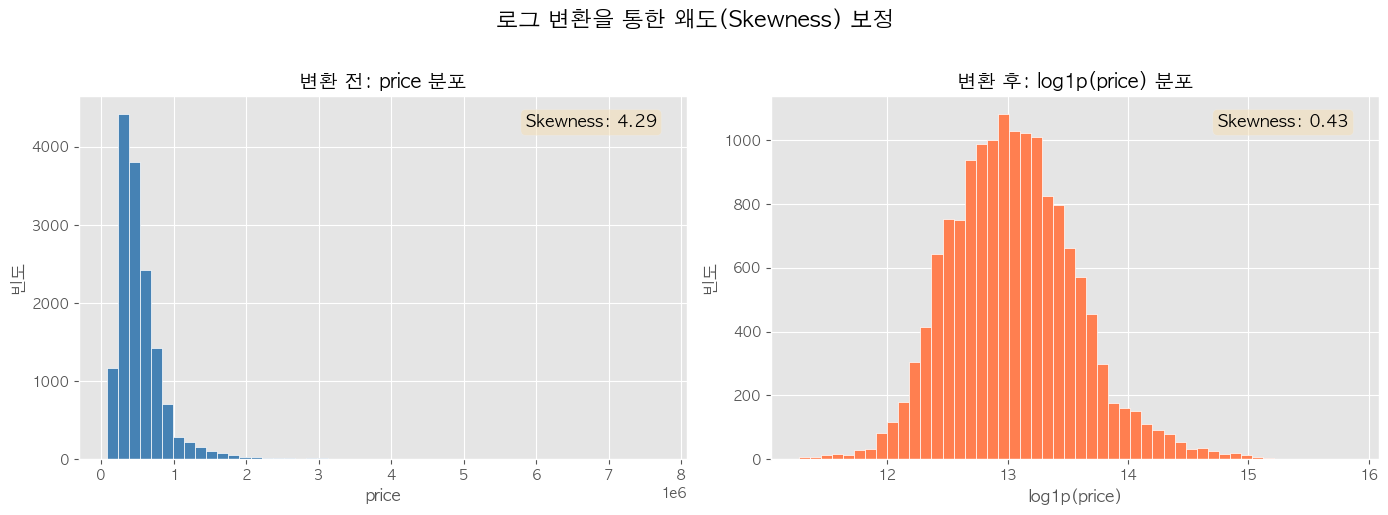

변환 전 왜도: 4.2936
변환 후 왜도: 0.4323

왜도가 0에 가까울수록 정규분포에 가깝습니다.


In [6]:
# 로그 변환 전후 비교: 히스토그램
train_data = data[data['data'] == 'train'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 변환 전
axes[0].hist(train_data['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('변환 전: price 분포', fontsize=14)
axes[0].set_xlabel('price')
axes[0].set_ylabel('빈도')
skew_before = train_data['price'].skew()
axes[0].text(0.95, 0.95, f'Skewness: {skew_before:.2f}',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 변환 후
price_log = np.log1p(train_data['price'])
axes[1].hist(price_log, bins=50, color='coral', edgecolor='white')
axes[1].set_title('변환 후: log1p(price) 분포', fontsize=14)
axes[1].set_xlabel('log1p(price)')
axes[1].set_ylabel('빈도')
skew_after = price_log.skew()
axes[1].text(0.95, 0.95, f'Skewness: {skew_after:.2f}',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('로그 변환을 통한 왜도(Skewness) 보정', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f'변환 전 왜도: {skew_before:.4f}')
print(f'변환 후 왜도: {skew_after:.4f}')
print(f'\n왜도가 0에 가까울수록 정규분포에 가깝습니다.')

In [7]:
# price에 로그 변환 적용
# np.log1p = log(1 + x): 0인 값도 안전하게 처리
# 나중에 원래 스케일로 복원할 때는 np.expm1 사용
data.loc[data['data'] == 'train', 'price'] = np.log1p(
    data.loc[data['data'] == 'train', 'price']
)

print('price 로그 변환 적용 완료!')
print(f"변환 후 price 범위: {data.loc[data['data']=='train', 'price'].min():.2f} ~ {data.loc[data['data']=='train', 'price'].max():.2f}")

price 로그 변환 적용 완료!
변환 후 price 범위: 11.26 ~ 15.86


---

## Step 3: Baseline 모델 (기준점 설정)

피처 엔지니어링의 효과를 정확히 측정하려면, 먼저 **아무 피처도 추가하지 않은 상태**의 성능을 알아야 합니다.
이것이 **Baseline(기준 모델)** 입니다.

### DevOps 비유
성능 튜닝을 할 때, 먼저 **현재 상태의 벤치마크**를 측정하고 나서 개선 작업을 시작하죠.
- Baseline 없이 "빨라졌다"고 말하면 → 근거 없는 주장
- Baseline 있으면 → "응답시간 200ms → 150ms, 25% 개선" 처럼 정량적 비교 가능

마찬가지로 ML에서도 Baseline Score를 먼저 측정한 뒤, 피처 엔지니어링으로 얼마나 개선되는지 확인합니다.

In [8]:
# Baseline: 원본 피처만 사용 (로그 변환된 price + 원본 피처)
baseline_data = data.drop('date', axis=1).copy()

print('Baseline 데이터 컬럼:')
print(baseline_data.columns.tolist())
print(f'\nBaseline 피처 수: {baseline_data.shape[1] - 3}개 (id, price, data 제외)')

Baseline 데이터 컬럼:
['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'data']

Baseline 피처 수: 18개 (id, price, data 제외)


Baseline 모델 (원본 피처만 사용)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[715]	train's rmse: 0.10174	valid's rmse: 0.161048
검증 점수 (RMSE): 104,278


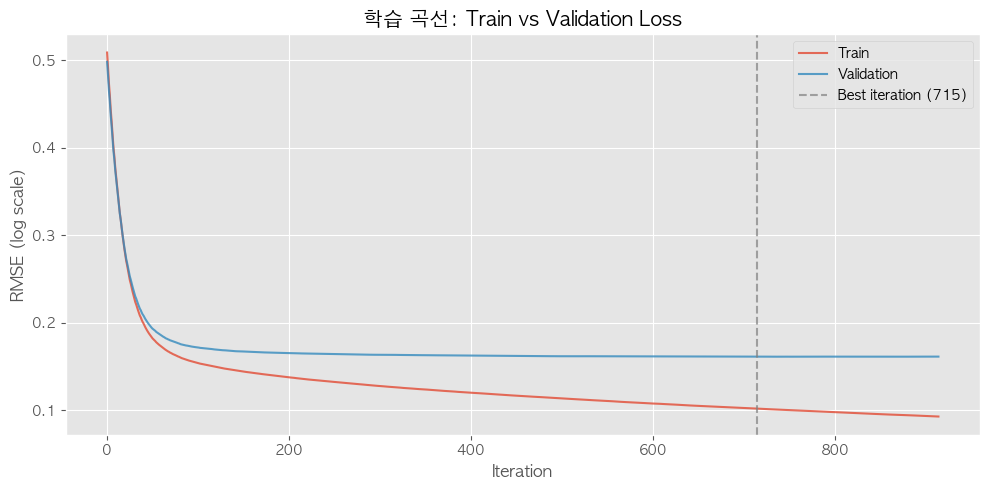


Baseline Score: 104,278
이 점수를 기억해 두세요. 피처 엔지니어링 후 얼마나 개선되는지 비교할 것입니다.


In [9]:
# Baseline 검증 점수 측정
print('=' * 50)
print('Baseline 모델 (원본 피처만 사용)')
print('=' * 50)

X_train_base, _, y_train_base = train_test_split_custom(baseline_data)
baseline_score = evaluate_lgb(X_train_base, y_train_base, lgb_param)

print(f'\nBaseline Score: {baseline_score:,.0f}')
print('이 점수를 기억해 두세요. 피처 엔지니어링 후 얼마나 개선되는지 비교할 것입니다.')

---

## Step 4: 시간 피처 생성

집이 **건축된 후 얼마나 경과했는지**는 집값에 큰 영향을 미칩니다.

`date` 컬럼에서 판매 년도를 추출하고, `yr_built`을 빼서 건축 후 경과 년수를 계산합니다.

### DevOps 비유
서버의 "가동 시간(uptime)"을 계산하는 것과 같습니다:
- `uptime = 현재 시각 - 서버 시작 시각`
- `건축 경과 년수 = 판매 년도 - 건축 년도`

In [10]:
# date 컬럼에서 판매 년도 추출
data['yr_sold'] = data['date'].apply(lambda x: int(x[:4]))

# 건축 후 경과 년수 계산
data['building_age'] = data['yr_sold'] - data['yr_built']

print('시간 피처 생성 완료!')
print(f"건축 경과 년수 범위: {data['building_age'].min()}년 ~ {data['building_age'].max()}년")
print(f"\n평균 건축 경과 년수: {data['building_age'].mean():.1f}년")

시간 피처 생성 완료!
건축 경과 년수 범위: -1년 ~ 115년

평균 건축 경과 년수: 43.3년


---

## Step 5: 비율 피처 생성

개별 피처의 절대값보다, **피처 간의 비율**이 더 의미 있는 정보를 담고 있을 때가 있습니다.

| 비율 피처 | 의미 |
|-----------|------|
| `bathrooms / bedrooms` | 침실당 욕실 수 (고급 주택일수록 높음) |
| `sqft_living / floors` | 층당 거주 면적 (넓을수록 쾌적) |
| `sqft_lot / sqft_living` | 대지 면적 대비 거주 면적 비율 (정원 크기 간접 지표) |

### DevOps 비유
- CPU 코어 수: 4개 (절대값)
- 코어당 요청 처리량: 250 req/core (비율) -- **이게 더 유용한 메트릭이죠!**

In [11]:
# 비율 피처 생성

# 침실당 욕실 수 (0으로 나누기 방지)
data['bath_per_bed'] = data['bathrooms'] / (data['bedrooms'] + 1)

# 층당 거주 면적
data['sqft_per_floor'] = data['sqft_living'] / (data['floors'] + 0.01)

# 대지 면적 대비 거주 면적 비율
data['lot_living_ratio'] = data['sqft_lot'] / (data['sqft_living'] + 1)

print('비율 피처 생성 완료!')
print(f"\nbath_per_bed 통계:")
print(data['bath_per_bed'].describe())
print(f"\nsqft_per_floor 통계:")
print(data['sqft_per_floor'].describe())
print(f"\nlot_living_ratio 통계:")
print(data['lot_living_ratio'].describe())

비율 피처 생성 완료!

bath_per_bed 통계:
count    21502.000000
mean         0.485128
std          0.153880
min          0.000000
25%          0.375000
50%          0.500000
75%          0.583333
max          2.500000
Name: bath_per_bed, dtype: float64

sqft_per_floor 통계:
count    21502.000000
mean      1473.459583
std        647.405303
min        252.491694
25%       1019.801980
50%       1358.208955
75%       1801.980198
max       9544.554455
Name: sqft_per_floor, dtype: float64

lot_living_ratio 통계:
count    21502.000000
mean         7.460394
std         22.991549
min          0.214787
25%          2.449780
50%          4.033052
75%          6.378455
max       1638.247539
Name: lot_living_ratio, dtype: float64


---

## Step 6: 불리언 피처 생성

연속형 값을 **"있다/없다"**로 단순화하면, 모델이 비선형 패턴을 더 쉽게 학습할 수 있습니다.

| 불리언 피처 | 원본 피처 | 의미 |
|-------------|-----------|------|
| `has_basement` | `sqft_basement > 0` | 지하실 유무 |
| `is_renovated` | `yr_renovated > 0` | 리모델링 여부 |

### DevOps 비유
- "메모리 사용량 78.3%"보다 `is_memory_critical = 메모리 > 80%`라는 불리언이
- 알림 규칙을 만들 때 더 직관적이고 유용한 것과 같습니다.

In [12]:
# 불리언 피처 생성

# 지하실 유무
data['has_basement'] = (data['sqft_basement'] > 0).astype(int)

# 리모델링 여부
data['is_renovated'] = (data['yr_renovated'] > 0).astype(int)

print('불리언 피처 생성 완료!')
print(f"\n지하실이 있는 집: {data['has_basement'].sum()}개 ({data['has_basement'].mean()*100:.1f}%)")
print(f"리모델링한 집: {data['is_renovated'].sum()}개 ({data['is_renovated'].mean()*100:.1f}%)")

불리언 피처 생성 완료!

지하실이 있는 집: 8446개 (39.3%)
리모델링한 집: 913개 (4.2%)


---

## Step 7: 상호작용 피처 (Interaction Features)

두 피처를 **곱하거나 조합**하여 새로운 의미를 만들어냅니다.

`sqft_living * grade`는 **"넓은 면적 + 높은 등급"**인 집을 더욱 강조합니다.
- 면적이 넓어도 등급이 낮으면 값이 작고
- 등급이 높아도 면적이 좁으면 값이 작습니다
- 둘 다 높을 때만 큰 값을 가지게 됩니다

### DevOps 비유
서버 성능 지표를 만들 때:
- `성능 점수 = CPU 코어 수 * 코어당 클럭 속도`
- 코어가 많아도 느리면 낮고, 빨라도 코어가 적으면 낮은 것과 같은 원리입니다.

In [13]:
# 상호작용 피처: 거주면적 * 등급
data['sqft_living_grade'] = data['sqft_living'] * data['grade']

print('상호작용 피처 생성 완료!')
print(f"\nsqft_living_grade 통계:")
print(data['sqft_living_grade'].describe())

상호작용 피처 생성 완료!

sqft_living_grade 통계:
count     21502.000000
mean      16757.865501
std       10173.043648
min         290.000000
25%       10080.000000
50%       14160.000000
75%       20640.000000
max      156650.000000
Name: sqft_living_grade, dtype: float64


---

## Step 8: Zipcode 분해 실습

미국 우편번호(zipcode)는 5자리 숫자로 구성되어 있으며, 각 자릿수가 지역 정보를 담고 있습니다.

5자리 우편번호를 다양한 방식으로 쪼개서 **다른 수준의 지역 정보**를 추출해 봅시다.

| 피처 | 설명 | 예시 (98178) |
|------|------|-------------|
| `zipcode_3` | 앞 3자리 (대분류 지역) | 981 |
| `zipcode_4` | 앞 4자리 (중분류 지역) | 9817 |
| `zipcode_5` | 전체 5자리 (소분류 지역) | 98178 |
| `zipcode_34` | 3~4번째 자리 | 17 |
| `zipcode_45` | 4~5번째 자리 | 78 |
| `zipcode_35` | 3번째와 5번째 자리 | 18 |

### DevOps 비유
IP 주소(192.168.1.100)를 분석할 때:
- `/8` 블록 (192.x.x.x) = 대분류 네트워크
- `/16` 블록 (192.168.x.x) = 중분류 네트워크
- `/24` 블록 (192.168.1.x) = 소분류 네트워크

같은 방식으로, 우편번호를 다양한 수준으로 분해하여 지역 정보를 추출합니다.

In [14]:
# zipcode를 문자열로 변환
data['zipcode_str'] = data['zipcode'].astype(int).astype(str)

# 다양한 수준의 zipcode 피처 생성
data['zipcode_3'] = data['zipcode_str'].apply(lambda x: x[:3])    # 앞 3자리
data['zipcode_4'] = data['zipcode_str'].apply(lambda x: x[:4])    # 앞 4자리
data['zipcode_5'] = data['zipcode_str'].apply(lambda x: x[:5])    # 전체 5자리
data['zipcode_34'] = data['zipcode_str'].apply(lambda x: x[2:4])  # 3~4번째 자리
data['zipcode_45'] = data['zipcode_str'].apply(lambda x: x[3:5])  # 4~5번째 자리
data['zipcode_35'] = data['zipcode_str'].apply(lambda x: x[2] + x[4])  # 3번째 + 5번째 자리

# 임시 컬럼 제거
data.drop('zipcode_str', axis=1, inplace=True)

print('Zipcode 분해 피처 생성 완료!')
print(f"\nzipcode_3 고유값 수: {data['zipcode_3'].nunique()}")
print(f"zipcode_4 고유값 수: {data['zipcode_4'].nunique()}")
print(f"zipcode_5 고유값 수: {data['zipcode_5'].nunique()}")
print(f"zipcode_34 고유값 수: {data['zipcode_34'].nunique()}")
print(f"zipcode_45 고유값 수: {data['zipcode_45'].nunique()}")
print(f"zipcode_35 고유값 수: {data['zipcode_35'].nunique()}")

Zipcode 분해 피처 생성 완료!

zipcode_3 고유값 수: 2
zipcode_4 고유값 수: 19
zipcode_5 고유값 수: 70
zipcode_34 고유값 수: 19
zipcode_45 고유값 수: 59
zipcode_35 고유값 수: 18


### Zipcode 피처 시각화

각 zipcode 피처를 지도 위에 시각화하여, **어떤 수준의 분해가 의미 있는 지역 구분을 만드는지** 확인합니다.

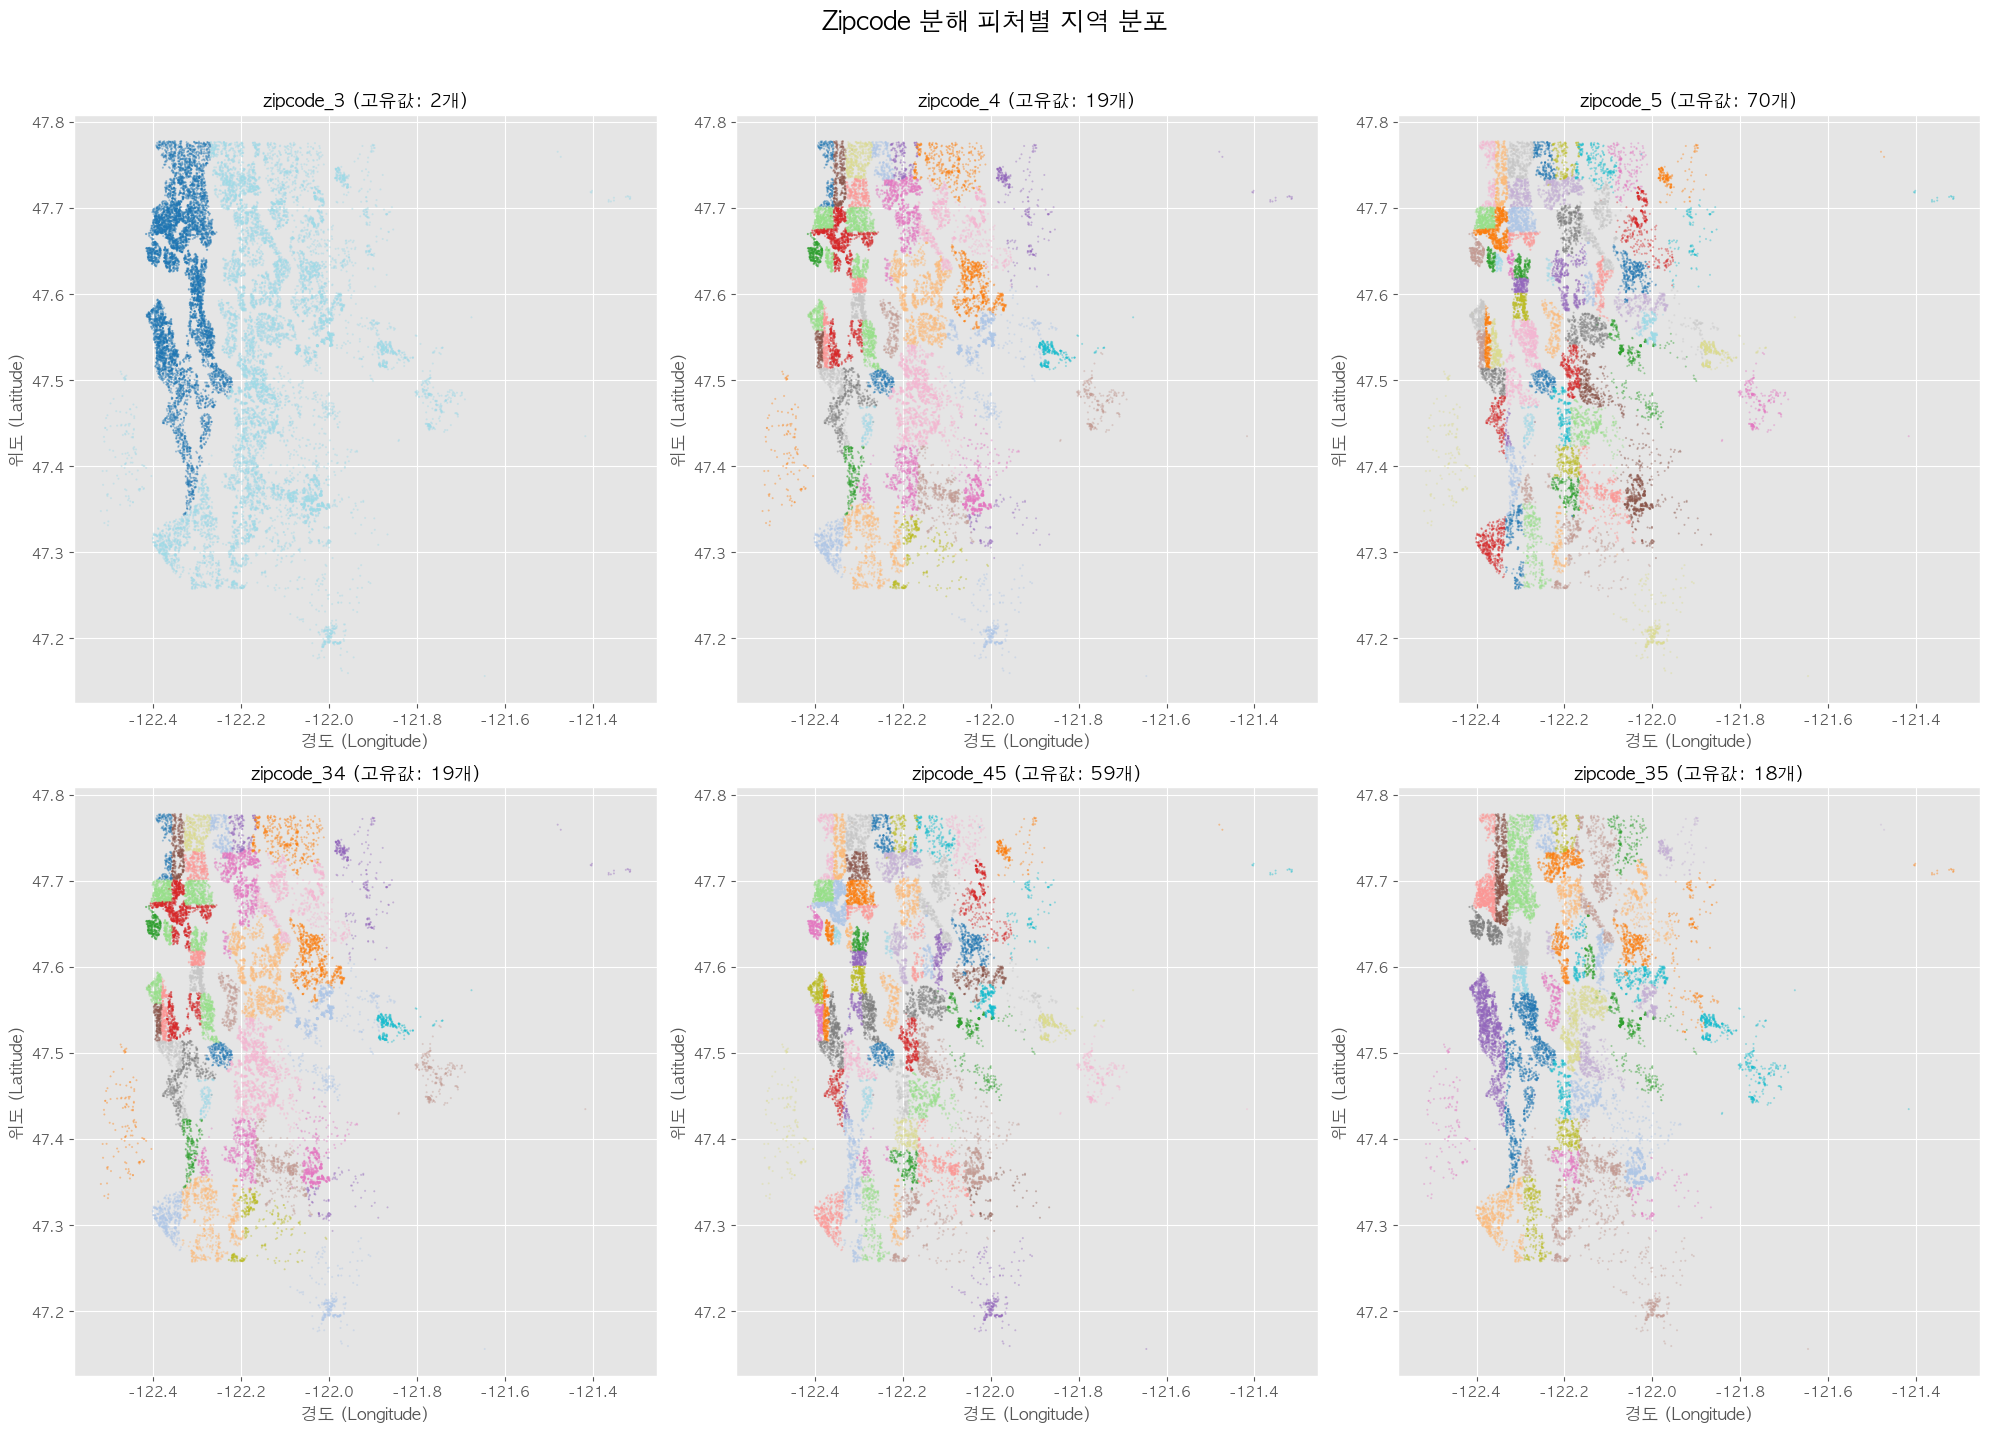

In [15]:
# zipcode 피처별 지도 시각화
zipcode_features = ['zipcode_3', 'zipcode_4', 'zipcode_5', 'zipcode_34', 'zipcode_45', 'zipcode_35']

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, feat in enumerate(zipcode_features):
    ax = axes[idx]
    
    # 카테고리를 숫자로 변환하여 색상 매핑
    codes, uniques = pd.factorize(data[feat])
    
    scatter = ax.scatter(
        data['long'], data['lat'],
        c=codes, cmap='tab20', alpha=0.3, s=1
    )
    ax.set_title(f'{feat} (고유값: {data[feat].nunique()}개)', fontsize=13)
    ax.set_xlabel('경도 (Longitude)')
    ax.set_ylabel('위도 (Latitude)')

plt.suptitle('Zipcode 분해 피처별 지역 분포', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 시각화 해석

- **zipcode_3**: 가장 넓은 범위. 이 데이터에서는 시애틀 지역이라 대부분 같은 값 (구분력 낮음)
- **zipcode_4, zipcode_5**: 세밀한 지역 구분 가능. 색상이 지리적으로 군집을 이루는 것을 확인할 수 있음
- **zipcode_34, zipcode_45, zipcode_35**: 기존 자릿수 조합으로 새로운 패턴을 포착할 수 있음

이처럼 하나의 피처에서도 **다양한 방식으로 정보를 추출**할 수 있습니다.

---

## Step 9: 피처 엔지니어링 효과 확인

모든 피처 엔지니어링이 완료되었습니다.

Step 3에서 측정한 Baseline과 비교하여 **성능이 얼마나 개선되었는지** 확인해 봅시다.

### 피처 엔지니어링 후 모델

In [16]:
# 피처 엔지니어링 적용된 데이터
fe_data = data.drop('date', axis=1).copy()

print('FE 후 데이터 컬럼:')
print(fe_data.columns.tolist())
print(f'\nFE 후 피처 수: {fe_data.shape[1] - 3}개 (id, price, data 제외)')

FE 후 데이터 컬럼:
['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'data', 'yr_sold', 'building_age', 'bath_per_bed', 'sqft_per_floor', 'lot_living_ratio', 'has_basement', 'is_renovated', 'sqft_living_grade', 'zipcode_3', 'zipcode_4', 'zipcode_5', 'zipcode_34', 'zipcode_45', 'zipcode_35']

FE 후 피처 수: 32개 (id, price, data 제외)


피처 엔지니어링 후 모델
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[670]	train's rmse: 0.0997419	valid's rmse: 0.158664
검증 점수 (RMSE): 102,456


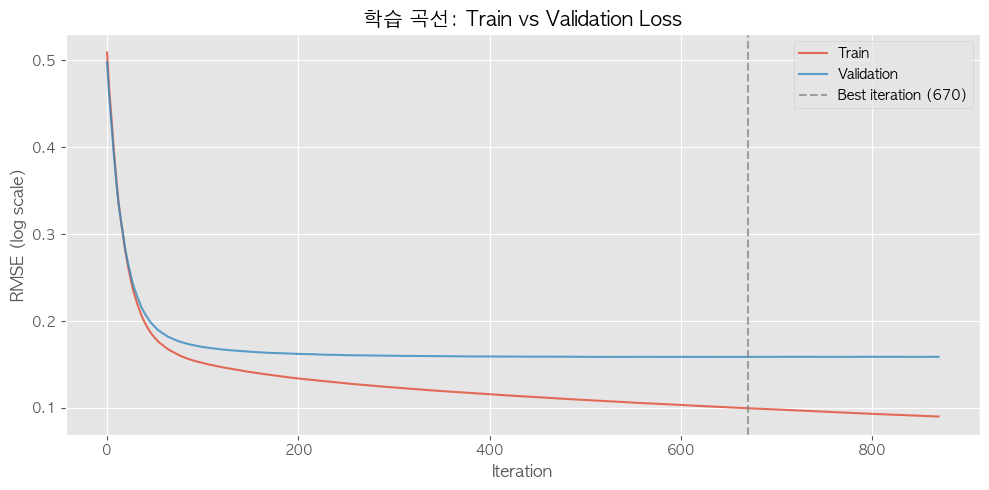

In [17]:
# 피처 엔지니어링 후 검증 점수 측정
print('=' * 50)
print('피처 엔지니어링 후 모델')
print('=' * 50)

X_train_fe, _, y_train_fe = train_test_split_custom(fe_data)
fe_score = evaluate_lgb(X_train_fe, y_train_fe, lgb_param)

### 결과 비교

        피처 엔지니어링 효과 비교
Baseline 검증 점수:       104,278
After FE 검증 점수:       102,456
개선 폭:                   1,823
개선율:                    1.75%


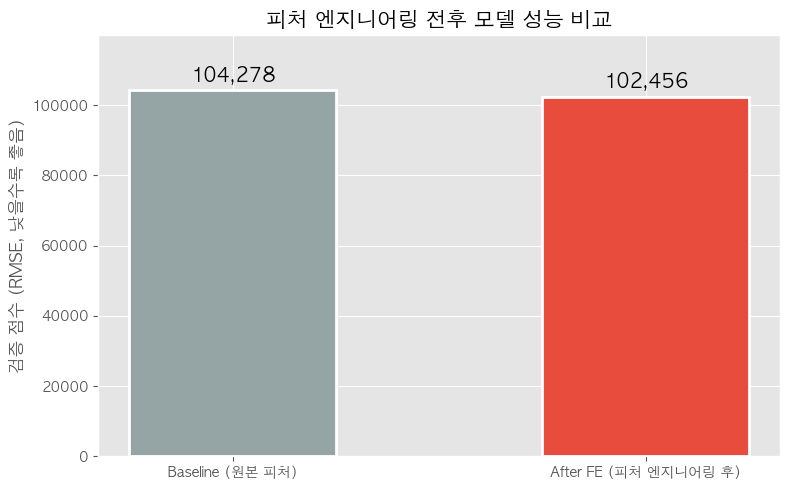

검증 점수(RMSE)가 낮을수록 예측이 정확합니다.
피처 엔지니어링만으로 약 $1,800의 예측 오차를 줄일 수 있었습니다!


In [18]:
# 결과 비교 시각화
print('=' * 50)
print('        피처 엔지니어링 효과 비교')
print('=' * 50)
print(f'Baseline 검증 점수:  {baseline_score:>12,.0f}')
print(f'After FE 검증 점수:  {fe_score:>12,.0f}')
print(f'개선 폭:            {baseline_score - fe_score:>12,.0f}')
print(f'개선율:             {(baseline_score - fe_score) / baseline_score * 100:>11.2f}%')
print('=' * 50)

# 막대 그래프로 비교
fig, ax = plt.subplots(figsize=(8, 5))

scores = [baseline_score, fe_score]
labels = ['Baseline (원본 피처)', 'After FE (피처 엔지니어링 후)']
colors = ['#95a5a6', '#e74c3c']

bars = ax.bar(labels, scores, color=colors, width=0.5, edgecolor='white', linewidth=2)

# 값 표시
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1500,
            f'{score:,.0f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('검증 점수 (RMSE, 낮을수록 좋음)', fontsize=12)
ax.set_title('피처 엔지니어링 전후 모델 성능 비교', fontsize=15)

# y축을 0부터 시작하여 왜곡 없이 표시
ax.set_ylim([0, max(scores) * 1.15])

plt.tight_layout()
plt.show()

print('검증 점수(RMSE)가 낮을수록 예측이 정확합니다.')
print('피처 엔지니어링만으로 약 $1,800의 예측 오차를 줄일 수 있었습니다!')

---

## 정리

### 오늘 배운 내용

| 기법 | 생성한 피처 | 설명 |
|------|------------|------|
| 로그 변환 | `log1p(price)` | 타겟 변수의 왜도 보정 |
| 시간 피처 | `building_age` | 건축 후 경과 년수 |
| 비율 피처 | `bath_per_bed`, `sqft_per_floor`, `lot_living_ratio` | 피처 간 관계를 비율로 표현 |
| 불리언 피처 | `has_basement`, `is_renovated` | 연속값을 유/무로 단순화 |
| 상호작용 피처 | `sqft_living_grade` | 두 피처의 곱으로 시너지 효과 포착 |
| 카테고리 분해 | `zipcode_3~5`, `zipcode_34/45/35` | 하나의 카테고리를 다양한 수준으로 분해 |

### 핵심 교훈

1. **도메인 지식이 핵심**: 데이터를 이해해야 좋은 피처를 만들 수 있습니다
2. **실험으로 검증**: 직감만으로는 부족합니다. 검증 점수로 효과를 검증해야 합니다
3. **작은 개선이 쌓인다**: 하나하나는 작아 보여도, 여러 피처가 모이면 큰 차이를 만듭니다

### DevOps 관점 요약

- 피처 엔지니어링은 **모니터링 메트릭 설계**와 같습니다
- 원본 로그보다 파생 메트릭이 더 유용하듯, 원본 피처보다 가공된 피처가 더 강력합니다
- 좋은 메트릭은 좋은 피처처럼 **도메인 지식 + 실험적 검증**의 산물입니다

---

## 다음 시간 예고

**Session 3: 위치 데이터 피처 엔지니어링**

- PCA(주성분 분석)로 좌표 변환하기
- K-Means 클러스터링으로 데이터 기반 "동네" 피처 만들기
- Haversine 거리로 이웃 탐색 및 통계 피처 생성하기